In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

airtel = "ISP 1"
jio = "ISP 2"
vi = "ISP 3"


def process_data(data):
	file_sizes = [102400, 204800, 307200, 409600, 512000, 614400, 716800, 819200, 921600, 1048576]
	data = data[data['file size(bytes)'].isin(file_sizes)]
	data['speed(kb/s)'] = data[' speed(bytes/s)']*8/1024
	data['file size(KB)'] = data['file size(bytes)']//1024
	data[' time taken(s)'] = pd.to_numeric(data[' time taken(s)'], errors='coerce')
	return data

In [2]:
# data_jio = pd.read_csv('jio_file_transfer.log')
data_jio = pd.read_csv('/home/vinet/ViNET_Testing/new_results/jio/jio-file-download.log')
data_airtel = pd.read_csv('/home/vinet/ViNET_Testing/new_results/airtel/airtel-file-download.log')
data_vi = pd.read_csv('/home/vinet/ViNET_Testing/new_results/vi/vi-file-download.log')

data_jio = process_data(data_jio.copy())
data_airtel = process_data(data_airtel.copy())
data_vi = process_data(data_vi.copy())

/tmp/ipykernel_275666/103222685.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['speed(kb/s)'] = data[' speed(bytes/s)']*8/1024
/tmp/ipykernel_275666/103222685.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['file size(KB)'] = data['file size(bytes)']//1024
/tmp/ipykernel_275666/103222685.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

In [11]:
data_airtel = pd.read_csv('new_logs/airtel-file-dowload.log')
data_airtel = process_data(data_airtel.copy())

In [12]:
data_vi = pd.read_csv('new_logs/vi-file-download.log')
data_vi = process_data(data_vi.copy())

In [3]:
# combine the data frames and add a new column for the ISP
data_jio['ISP'] = jio
data_airtel['ISP'] = airtel
data_vi['ISP'] = vi
data = pd.concat([data_airtel, data_jio, data_vi], ignore_index=True)

data

,file size(bytes),time taken(s),speed(bytes/s),speed(kb/s),file size(KB),ISP
0,102400,6.552504,15627.0,122.085938,100,ISP 1
1,102400,5.529106,18520.0,144.687500,100,ISP 1
2,102400,12.434082,8235.0,64.335938,100,ISP 1
3,102400,12.594526,8130.0,63.515625,100,ISP 1
4,102400,12.381034,8270.0,64.609375,100,ISP 1
...,...,...,...,...,...,...
432,1048576,127.306639,8236.0,64.343750,1024,ISP 3
433,1048576,128.218358,8178.0,63.890625,1024,ISP 3
434,1048576,126.622586,8281.0,64.695312,1024,ISP 3
435,1048576,130.028799,8064.0,63.000000,1024,ISP 3


In [9]:
# print all rows where ISP is ISP 1
print(data[data['ISP'] == airtel])

    file size(bytes)   time taken(s)   speed(bytes/s)  speed(kb/s)  \
0             102400        6.552504            15627   122.085938   
1             102400        5.529106            18520   144.687500   
2             102400       12.434082             8235    64.335938   
3             102400       12.594526             8130    63.515625   
4             102400       12.381034             8270    64.609375   
5             102400       11.224459             9122    71.265625   
6             102400       12.588578             8134    63.546875   
7             102400       12.502232             8190    63.984375   
8             102400       12.272399             8343    65.179688   
9             102400       12.997862             7878    61.546875   
10            204800       24.976153             8199    64.054688   
11            204800       25.313612             8090    63.203125   
12            204800       26.400677             7757    60.601562   
13            204800

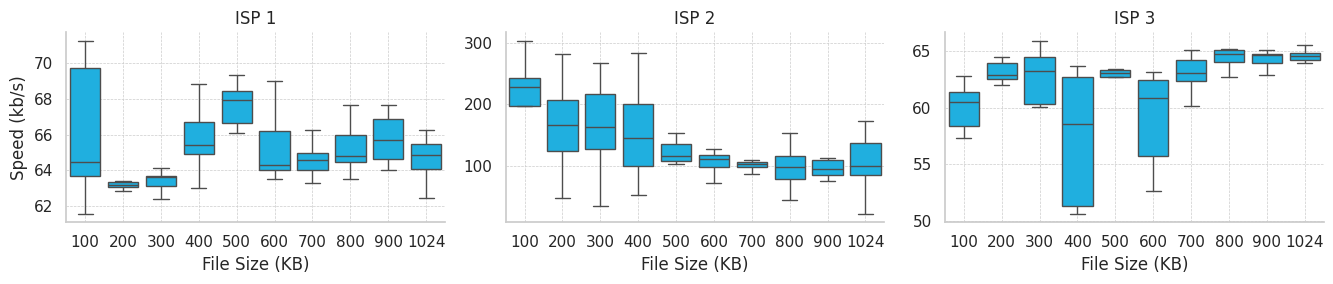

In [26]:
sns.set_theme(style="whitegrid")

# Create faceted boxplots, one per ISP
g = sns.FacetGrid(
    data, 
    col="ISP", 
    col_wrap=3,        # Wrap plots in a row
    sharey=False,      # Allow different y-scales for each ISP
    height=3, 
    aspect=1.5         # Wider aspect ratio for clarity
)

# Draw boxplots for each ISP facet
g.map_dataframe(
    sns.boxplot,
    x="file size(KB)", 
    y="speed(kb/s)", 
    color='deepskyblue',
    showfliers=False,
)

# Customize each subplot
g.set_titles(col_template="{col_name}")
g.set_axis_labels("File Size (KB)", "Speed (kb/s)")
for ax in g.axes.flatten():

    ax.tick_params(axis='x')  # Rotate x-labels for readability
    ax.grid(True, linestyle='--', linewidth=0.5)

# Optional: Adjust layout and add main title
plt.subplots_adjust(top=0.85)
# g.fig.suptitle("File download spped using ViNET across different ISPs", fontsize=12)

plt.tight_layout()
plt.savefig('/home/vinet/sec_analysis/ml_pipeline/paper_figures/file_download_speed.pdf', bbox_inches='tight')
plt.show()

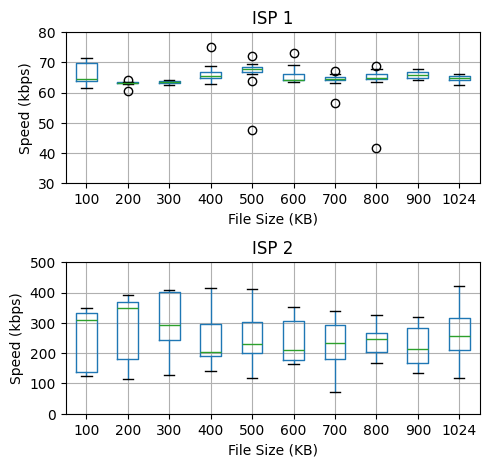

In [26]:
fig, axs = plt.subplots(2, 1)
fig.set_size_inches(5, 5)
data_jio.boxplot(column="speed(kb/s)", by="file size(KB)", grid=False, ax=axs[1])
data_airtel.boxplot(column="speed(kb/s)", by="file size(KB)", grid=False, ax=axs[0])
axs[1].set_title(jio)
axs[1].set_xlabel("File Size (KB)")
axs[1].set_ylabel("Speed (kbps)")
axs[1].grid()
axs[1].set_ylim(0, 500)
axs[0].set_title(airtel)
axs[0].set_xlabel("File Size (KB)")
axs[0].set_ylabel("Speed (kbps)")
axs[0].grid()
axs[0].set_ylim(30, 80)

plt.suptitle("")
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# save the figure as pdf
fig.savefig('file_transfer_speed.pdf', bbox_inches='tight')


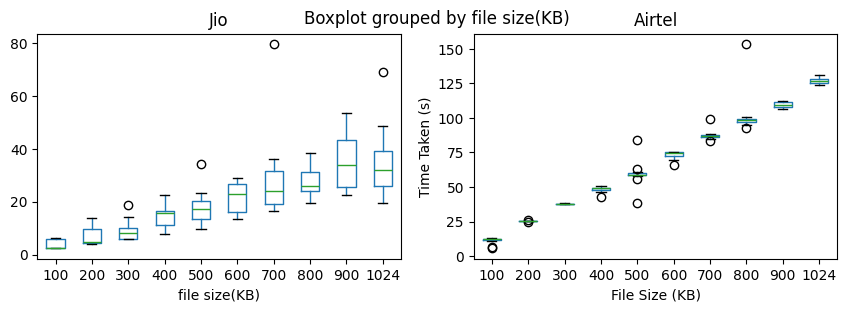

In [20]:
fig, axs = plt.subplots(1, 2)
fig.set_size_inches(10, 3)
data_jio.boxplot(column=" time taken(s)", by="file size(KB)", grid=False, ax=axs[0])
data_airtel.boxplot(column=" time taken(s)", by="file size(KB)", grid=False, ax=axs[1])
axs[0].set_title("Jio")
axs[1].set_title("Airtel")
plt.xlabel("File Size (KB)")
plt.ylabel("Time Taken (s)")
plt.show()